# signals.ipynb — Construcción de señales y retornos de estrategia

**Propósito:** Toma `prices_adjusted.csv` y genera series de retornos diarios por estrategia, guardadas en `data/signals/daily_returns_XXXX.csv`.

**Flujo:**
1. Cargar precios ajustados + configuración
2. Funciones de señal: MA gradual, binaria, position sizing
3. Aplicar señales a cada estrategia
4. Guardar `daily_returns_XXXX.csv` en `data/signals/`

**Pre-requisito:** `research.ipynb` ya corrido.  
**Output:** `data/signals/daily_returns_STRAT001.csv`, `...002.csv`, etc.  
**Referencia:** MScFE SKILL §5, §6, López de Prado §4


In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import sys

BASE    = Path('/content/drive/MyDrive/portfolio_quant')
CONFIG  = BASE / 'config'
DATA    = BASE / 'data'
SIGNALS = DATA / 'signals'
SIGNALS.mkdir(exist_ok=True)

SKILLS = BASE / 'vendor' / 'gauss314_skills' / 'skills' / 'portfolio'
if SKILLS.exists() and str(SKILLS) not in sys.path:
    sys.path.insert(0, str(SKILLS))

print('prices_adjusted.csv:', (DATA / 'prices_adjusted.csv').exists())
print('signals/ dir:', SIGNALS.exists())

Mounted at /content/drive
prices_adjusted.csv: True
signals/ dir: True


In [2]:
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt

TRADING_DAYS = 252

try:
    cr_df     = pd.read_csv(CONFIG / 'costs_rates.csv')
    rf_annual = float(cr_df.loc[cr_df['parameter'] == 'risk_free_rate', 'value'].iloc[0])
except Exception:
    rf_annual = 0.02
    print('[warn] rf_annual=0.02 por defecto')

try:
    rules          = yaml.safe_load((CONFIG / 'rules.yaml').read_text())
    ma_length      = rules['signals']['primary']['ma_length']
    apply_fraction = rules['signals']['primary']['apply_fraction']
except Exception:
    ma_length, apply_fraction = 15, 1/6
    print('[warn] ma_length=15, apply_fraction=1/6 por defecto')

print(f'rf_annual={rf_annual:.2%} | ma_length={ma_length} | apply_fraction={apply_fraction:.4f}')

rf_annual=2.00% | ma_length=15 | apply_fraction=0.1667


In [3]:
prices_adjusted = pd.read_csv(
    DATA / 'prices_adjusted.csv',
    parse_dates=['date'],
    index_col='date'
).sort_index()

returns_daily = prices_adjusted.pct_change().dropna(how='all')

print(f'Panel: {prices_adjusted.shape}')
print(f'Período: {prices_adjusted.index.min().date()} → {prices_adjusted.index.max().date()}')
print(f'Columnas disponibles: {list(prices_adjusted.columns)}')

Panel: (3654, 24)
Período: 2016-06-17 → 2026-06-18
Columnas disponibles: ['AGG', 'BOXX', 'BTC-USD', 'DBC', 'DBMF', 'EEM', 'EFA', 'EMB', 'GLD', 'HYG', 'IEF', 'LQD', 'PFF', 'RSSB', 'RSST', 'SHY', 'SLV', 'SPY', 'TIP', 'TLT', 'USO', 'VEA', 'VNQ', 'VT']


/tmp/ipykernel_19746/1752472904.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_daily = prices_adjusted.pct_change().dropna(how='all')


## Funciones de señal

Todas las señales usan datos de **t-1** para la posición en **t** (sin look-ahead bias).  
Ref: MScFE SKILL §8.2 (Trap 5)


In [4]:
# ── FUNCIONES DE SEÑAL ────────────────────────────────────────────────────────

def signal_ma_binary(price_series: pd.Series, ma_window: int = 15) -> pd.Series:
    """
    Señal binaria: 1 si precio > MA, 0 si precio < MA. Desplazada 1 día.
    Args:
        price_series (pd.Series): Precios ajustados.
        ma_window    (int):       Ventana MA en días.
    Returns:
        pd.Series: Posición {0, 1}.
    """
    ma         = price_series.rolling(ma_window).mean()
    signal_raw = (price_series > ma).astype(float)
    return signal_raw.shift(1).fillna(0.0)


def signal_ma_gradual(price_series: pd.Series, ma_window: int = 15,
                      step: float = 1/6, rebal_days_signal: int = 14) -> pd.Series:
    """
    Señal gradual: cambia posición en `step` cada `rebal_days_signal` días.
    Desplazada 1 día (sin look-ahead).
    Args:
        price_series       (pd.Series): Precios ajustados.
        ma_window          (int):       Ventana MA. Default 15.
        step               (float):     Fracción de cambio. Default 1/6.
        rebal_days_signal  (int):       Días entre rebalanceos. Default 14.
    Returns:
        pd.Series: Posición en [0, 1].
    """
    ma             = price_series.rolling(ma_window).mean()
    below          = (price_series < ma).fillna(False)
    hedge_fraction = 0.0
    position_list  = []
    last_rebal_idx = None

    for i, (dt, is_below) in enumerate(below.items()):
        if last_rebal_idx is None or (i - last_rebal_idx) >= rebal_days_signal:
            if is_below:
                hedge_fraction = min(1.0, hedge_fraction + step)
            else:
                hedge_fraction = max(0.0, hedge_fraction - step)
            last_rebal_idx = i
        position_list.append(1.0 - hedge_fraction)

    position_series = pd.Series(position_list, index=price_series.index)
    return position_series.shift(1).fillna(1.0)


def compute_position_sizing_equal(ticker_list: list, prices_panel: pd.DataFrame) -> pd.DataFrame:
    """
    Pesos iguales entre tickers disponibles en cada fecha.
    Ref: MScFE SKILL §3.1 (equal weight baseline).
    Args:
        ticker_list   (list):         Tickers a incluir.
        prices_panel  (pd.DataFrame): Panel de precios ajustados.
    Returns:
        pd.DataFrame: Pesos diarios en [0,1] por ticker. Suman a 1 por fila.
    """
    available   = [t for t in ticker_list if t in prices_panel.columns]
    valid_mask  = prices_panel[available].notna()
    row_counts  = valid_mask.sum(axis=1).replace(0, np.nan)
    weights_df  = valid_mask.div(row_counts, axis=0).fillna(0.0)
    return weights_df


print('signal_ma_binary | signal_ma_gradual | compute_position_sizing_equal')

signal_ma_binary | signal_ma_gradual | compute_position_sizing_equal


In [5]:
# ── FUNCIÓN CORE: CONSTRUIR RETORNOS DE ESTRATEGIA ────────────────────────────

def build_strategy_returns(
    system_tickers: list,
    hedge_map:      dict,
    weights_df:     pd.DataFrame,
    signal_fn,
    collateral_tickers: list = ['BOXX', 'SHY'],
    costs_bps:  float = 10.0,
    rebal_days: int   = 14,
    **signal_kwargs
) -> pd.Series:
    """
    Construye serie de retornos diarios para una estrategia.
    Señal en t-1, costos en bps cada rebal_days días.

    Args:
        system_tickers     (list):         Tickers del sistema.
        hedge_map          (dict):         ticker → instrumento hedge o None.
        weights_df         (pd.DataFrame): Pesos por ticker y fecha.
        signal_fn          (callable):     Función de señal (price_series, **kwargs).
        collateral_tickers (list):         Orden de preferencia colateral.
        costs_bps          (float):        Costos transacción en bps.
        rebal_days         (int):          Días entre rebalanceos.
        **signal_kwargs:   Parámetros para signal_fn.

    Returns:
        pd.Series: Retornos diarios de la estrategia.
    """
    collateral_col     = next((t for t in collateral_tickers if t in returns_daily.columns), None)
    returns_collateral = returns_daily[collateral_col] if collateral_col else pd.Series(0.0, index=returns_daily.index)

    tickers_available = [t for t in system_tickers if t in returns_daily.columns]
    if not tickers_available:
        raise ValueError(f'Ningún ticker disponible: {system_tickers}')

    # Señales por ticker (posición larga en [0,1])
    position_signals = {}
    for ticker in tickers_available:
        if ticker in prices_adjusted.columns:
            position_signals[ticker] = signal_fn(prices_adjusted[ticker], **signal_kwargs)
        else:
            position_signals[ticker] = pd.Series(1.0, index=prices_adjusted.index)

    strategy_returns = []
    last_rebal_date  = None
    common_index     = returns_daily[tickers_available].dropna(how='all').index

    for dt in common_index:
        if last_rebal_date is None:
            cost = 0.0
            last_rebal_date = dt
        elif (dt - last_rebal_date).days >= rebal_days:
            cost = costs_bps / 10_000
            last_rebal_date = dt
        else:
            cost = 0.0

        daily_ret = 0.0
        for ticker in tickers_available:
            w_asset   = weights_df.loc[dt, ticker] if dt in weights_df.index and ticker in weights_df.columns else 1.0 / len(tickers_available)
            pos_long  = position_signals[ticker].get(dt, 1.0)
            ret_asset = returns_daily.loc[dt, ticker] if dt in returns_daily.index else 0.0
            ret_coll  = returns_collateral.get(dt, 0.0)
            if pd.isna(ret_asset):
                ret_asset = 0.0
            daily_ret += w_asset * (pos_long * ret_asset + (1.0 - pos_long) * ret_coll)

        strategy_returns.append(daily_ret - cost)

    return pd.Series(strategy_returns, index=common_index, name='daily_return')


print('build_strategy_returns() definida')

build_strategy_returns() definida


## STRAT-001 — Sistema Return Stacking con Hedge Gradual

Parámetros según `portfolio_strategies.md` y `rules.yaml`.


In [6]:
STRAT001_ID      = 'STRAT001'
strat001_tickers = ['RSSB', 'RSST', 'GLD', 'SLV', 'TIP', 'HYG', 'PFF']
strat001_hedge   = {'RSSB': 'VT', 'RSST': 'SPY', 'GLD': None, 'SLV': None}

strat001_available = [t for t in strat001_tickers if t in prices_adjusted.columns]
print(f'STRAT-001 tickers disponibles: {strat001_available}')
if len(strat001_available) < len(strat001_tickers):
    missing = [t for t in strat001_tickers if t not in prices_adjusted.columns]
    print(f'  [warn] Faltantes: {missing}')

weights_strat001 = compute_position_sizing_equal(strat001_available, prices_adjusted)

returns_strat001 = build_strategy_returns(
    system_tickers=strat001_available,
    hedge_map=strat001_hedge,
    weights_df=weights_strat001,
    signal_fn=signal_ma_gradual,
    collateral_tickers=['BOXX', 'SHY'],
    costs_bps=10.0,
    rebal_days=14,
    ma_window=ma_length,
    step=apply_fraction,
    rebal_days_signal=14,
)

output_path_001 = SIGNALS / f'daily_returns_{STRAT001_ID}.csv'
returns_strat001.to_frame('daily_return').to_csv(output_path_001)
print(f'STRAT-001 guardado: {output_path_001}')
print(f'Período: {returns_strat001.index.min().date()} → {returns_strat001.index.max().date()}')
print(f'Retorno medio diario: {returns_strat001.mean():.4%}')

STRAT-001 tickers disponibles: ['RSSB', 'RSST', 'GLD', 'SLV', 'TIP', 'HYG', 'PFF']
STRAT-001 guardado: /content/drive/MyDrive/portfolio_quant/data/signals/daily_returns_STRAT001.csv
Período: 2016-06-18 → 2026-06-18
Retorno medio diario: 0.0396%


## STRAT-002 — 60/40 SPY/AGG (Benchmark)


In [7]:
STRAT002_ID           = 'STRAT002'
strat002_tickers      = ['SPY', 'AGG']
strat002_weights_fixed = {'SPY': 0.60, 'AGG': 0.40}

strat002_available = [t for t in strat002_tickers if t in returns_daily.columns]
print(f'STRAT-002 tickers disponibles: {strat002_available}')

if len(strat002_available) == 0:
    print('[ERROR] SPY o AGG no disponibles en el panel.')
else:
    def signal_always_long(price_series, **kwargs):
        return pd.Series(1.0, index=price_series.index)

    weights_strat002 = pd.DataFrame(
        {t: strat002_weights_fixed.get(t, 0.0) for t in strat002_available},
        index=prices_adjusted.index
    )

    returns_strat002 = build_strategy_returns(
        system_tickers=strat002_available,
        hedge_map={},
        weights_df=weights_strat002,
        signal_fn=signal_always_long,
        costs_bps=5.0,
        rebal_days=21,
    )

    output_path_002 = SIGNALS / f'daily_returns_{STRAT002_ID}.csv'
    returns_strat002.to_frame('daily_return').to_csv(output_path_002)
    print(f'STRAT-002 guardado: {output_path_002}')
    print(f'Retorno medio diario: {returns_strat002.mean():.4%}')

STRAT-002 tickers disponibles: ['SPY', 'AGG']
STRAT-002 guardado: /content/drive/MyDrive/portfolio_quant/data/signals/daily_returns_STRAT002.csv
Retorno medio diario: 0.0386%


## STRAT-003 — Trend Following puro (señal binaria)


In [8]:
STRAT003_ID = 'STRAT003'

if 'SPY' not in prices_adjusted.columns:
    print('[SKIP] SPY no disponible en el panel')
else:
    weights_strat003 = compute_position_sizing_equal(['SPY'], prices_adjusted)

    returns_strat003 = build_strategy_returns(
        system_tickers=['SPY'],
        hedge_map={},
        weights_df=weights_strat003,
        signal_fn=signal_ma_binary,
        collateral_tickers=['BOXX', 'SHY'],
        costs_bps=5.0,
        rebal_days=1,
        ma_window=ma_length,
    )

    output_path_003 = SIGNALS / f'daily_returns_{STRAT003_ID}.csv'
    returns_strat003.to_frame('daily_return').to_csv(output_path_003)
    print(f'STRAT-003 guardado: {output_path_003}')
    print(f'Retorno medio diario: {returns_strat003.mean():.4%}')

STRAT-003 guardado: /content/drive/MyDrive/portfolio_quant/data/signals/daily_returns_STRAT003.csv
Retorno medio diario: -0.0374%


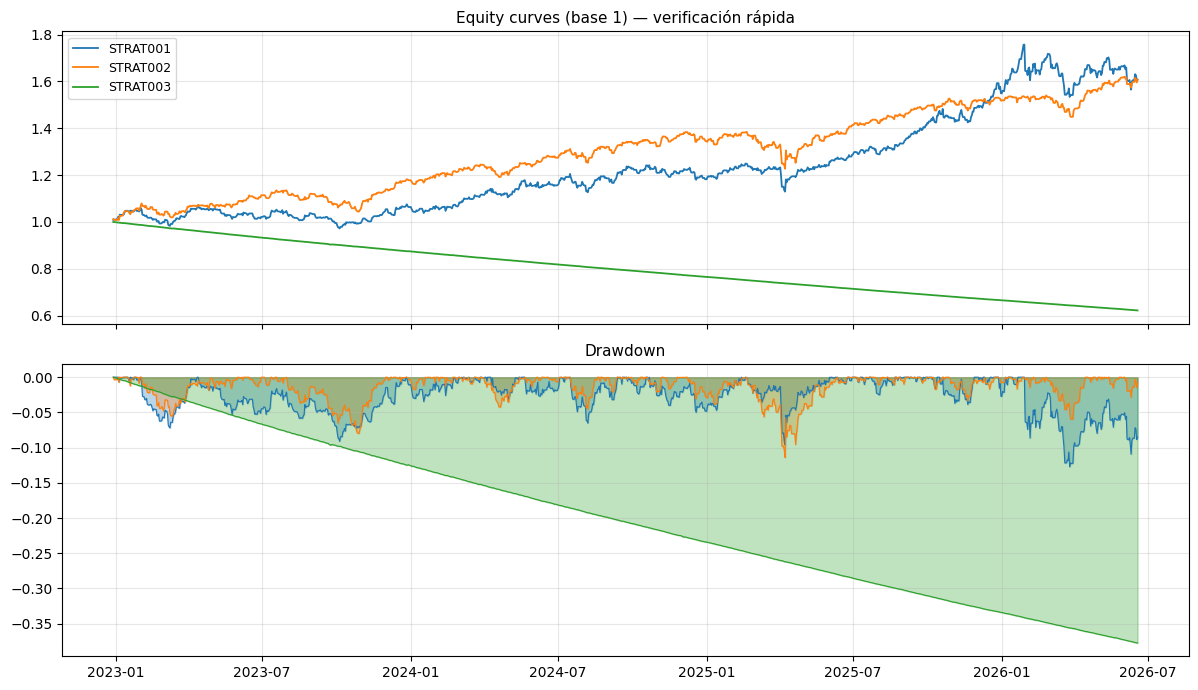


Archivos en data/signals/:
  daily_returns_STRAT001.csv: 3653 filas
  daily_returns_STRAT002.csv: 3653 filas
  daily_returns_STRAT003.csv: 3653 filas


In [9]:
# ── VERIFICACIÓN VISUAL RÁPIDA ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

strategies_to_plot = {}
for strat_id in ['STRAT001', 'STRAT002', 'STRAT003']:
    csv_path = SIGNALS / f'daily_returns_{strat_id}.csv'
    if csv_path.exists():
        df = pd.read_csv(csv_path, parse_dates=['date'], index_col='date')
        strategies_to_plot[strat_id] = df['daily_return']

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for (name, ret_series), color in zip(strategies_to_plot.items(), colors):
    equity_curve = (1 + ret_series.dropna()).cumprod()
    axes[0].plot(equity_curve, label=name, color=color, linewidth=1.3)
    drawdown = equity_curve / equity_curve.cummax() - 1
    axes[1].fill_between(drawdown.index, drawdown, 0, alpha=0.3, color=color)
    axes[1].plot(drawdown, color=color, linewidth=0.8, label=name)

axes[0].set_title('Equity curves (base 1) — verificación rápida', fontsize=11)
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
axes[1].set_title('Drawdown', fontsize=11); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\nArchivos en data/signals/:')
for f in sorted(SIGNALS.glob('*.csv')):
    n_rows = sum(1 for _ in open(f)) - 1
    print(f'  {f.name}: {n_rows} filas')